# 옥수수 수확량 예측 — 전체 재현 노트북

이 노트북 **하나만** 있으면 데이터 로딩부터 최종 결과·그림까지 전 과정을 재현할 수 있다.
데이터가 노트북 안에 압축 내장되어 있어 외부 파일이 필요 없다.

**우리가 푸는 문제 (두 단계):**
1. **기본 예측** — 미국 카운티×연도(1981–2015) 기후·토양 데이터로 옥수수 수확량(bu/ac)을 예측한다.
2. **극단해 인식** — 2012년 대가뭄 같은 '흉작(붕괴)'을 표준 예측이 놓치는 문제를 풀기 위해,
   숫자 하나 대신 **하방 위험(얼마나 나빠질 수 있나)** 을 예측한다.

**핵심 모델**: HistGradientBoosting (그래디언트 부스팅 트리) — 점추정 + 분위수 예측.
**목차**: 1. 데이터 · 2. 전처리 · 3. 모델 · 4. 평가 · 5. 결과 · 6. 재현성

## 1. 사용한 데이터

**① 무엇:** 미국 옥수수 주산지(Corn Belt) 12개 주의 카운티×연도 패널 데이터를 불러온다.
**② 왜:** 수확량이 기후·토양에 따라 어떻게 달라지는지 배우려면, 여러 지역·여러 해의 실제
기록이 필요하다.
**③ 코드:** 아래 `DATA_B64` 는 6개 원본 파일(수확량·온도·강수·토양·가뭄·토양수분)을 이미
카운티(`stco`)·연도(`year`)로 병합해 gzip 압축한 것이다. 푸는 즉시 `df` 로 쓴다.

**데이터 출처와 각 파일의 역할**

| 원본 | 내용 | 출처 |
|---|---|---|
| yielddata | 옥수수 수확량 (bu/ac) — **타깃** | USDA NASS |
| gddMarAug | 온도 노출 → gdd·edd 로 압축 | ACDC (Schlenker-Roberts) |
| pptMarAug | 생육기 강수 | ACDC |
| soil2011 | 토양 특성 | gSSURGO |
| USDM | 7월 가뭄지수(dsci_jul) | US Drought Monitor |
| TerraClimate | 7월 토양수분·강수·최고기온 | TerraClimate(GEE) |

**각 컬럼의 의미**

| 컬럼 | 의미 | 단위 |
|---|---|---|
| `stco` `state` `year` | 카운티 FIPS · 주 · 연도 | 키(key) |
| `corn` | 옥수수 수확량 (**타깃 변수**) | bu/ac |
| `gdd` | 유익열 도일 (10–29℃) | ℃·일 |
| `edd` | 극한고온 도일 (30℃↑) | ℃·일 |
| `ppt` | 생육기 총강수 | mm |
| `whc` `om` `spH` `clay` `slope` | 토양: 보수력·유기물·산도·점토·경사 | — |
| `dsci_jul` | 7월 가뭄지수 (2000년~) | 0–500 |
| `soil_jul` `pr_jul` `tmmx_jul` | 7월 토양수분·강수·최고기온 | — |

**④ 의미:** 아래를 실행하면 데이터 크기(행·열)와 타깃(`corn`)의 분포를 확인할 수 있다.
**⑤ 다음:** 이 표를 2단계에서 '전처리'해 모델이 먹을 수 있는 형태로 만든다.

In [1]:
DATA_B64 = "..."

import base64, gzip, io, os
import numpy as np             
import pandas as pd             
import matplotlib.pyplot as plt 
from matplotlib import font_manager as _fm
plt.rcParams.update({"figure.dpi": 100, "font.size": 11, "axes.grid": True, "grid.alpha": .3})
for _p in ["/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc",
           "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(_p):
        _fm.fontManager.addfont(_p); plt.rcParams["font.family"] = _fm.FontProperties(fname=_p).get_name(); break
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(DATA_B64))))

print("데이터 크기 (행, 열):", df.shape)
print("기간:", int(df.year.min()), "~", int(df.year.max()), "| 카운티 수:", df.stco.nunique())
print("타깃 변수 corn(bu/ac) — 평균 %.1f, 최소 %.1f, 최대 %.1f" % (df.corn.mean(), df.corn.min(), df.corn.max()))
df.head()

데이터 크기 (행, 열): (34627, 16)
기간: 1981 ~ 2015 | 카운티 수: 1113
타깃 변수 corn(bu/ac) — 평균 118.4, 최소 0.0, 최대 236.0


,stco,state,year,corn,gdd,edd,ppt,whc,om,spH,clay,slope,dsci_jul,soil_jul,pr_jul,tmmx_jul
0,17001,17,1981,116.0,144.9,9.3,982.7540,34.8166,153.8438,6.2865,28.1477,100.5731,NaN,1193.386,302.551,291.621
1,17003,17,1981,100.0,137.3,26.8,788.6962,31.6414,174.4598,6.5033,27.0825,47.0458,NaN,1614.716,187.410,318.304
2,17005,17,1981,109.0,140.3,18.1,759.8871,26.1186,103.8926,6.1654,28.4206,58.5840,NaN,1374.378,190.128,306.003
3,17007,17,1981,123.0,136.9,4.0,674.2255,26.8755,258.0167,6.6681,24.4326,85.5528,NaN,211.926,86.611,269.565
4,17009,17,1981,131.0,144.6,9.2,998.1249,31.5379,124.5589,6.2671,28.6716,107.8786,NaN,1308.802,288.729,294.022


아래는 타깃(`corn`)이 어떻게 생겼는지 눈으로 보는 그림이다. 왼쪽은 수확량 분포(히스토그램),
오른쪽은 연도별 평균 수확량이다. **오른쪽에서 수확량이 매년 조금씩 오르는 것**(기술 발전)과,
**2012년에 뚝 떨어진 것**(대가뭄)이 보인다 — 이 2012년 붕괴가 이 노트북의 주인공이다.

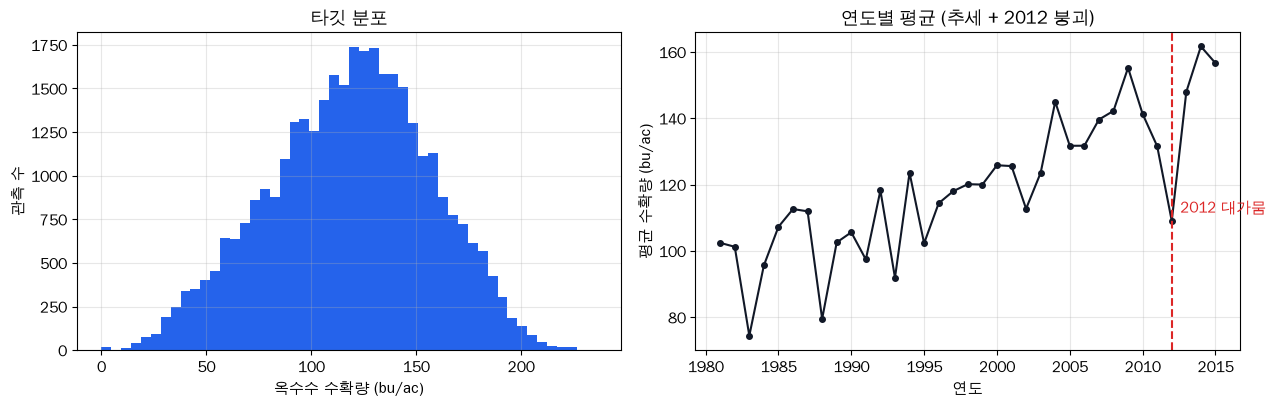

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
# (왼쪽) 수확량 분포
ax[0].hist(df.corn, bins=50, color="#2563eb")
ax[0].set(xlabel="옥수수 수확량 (bu/ac)", ylabel="관측 수", title="타깃 분포")
# (오른쪽) 연도별 평균
yr_mean = df.groupby("year").corn.mean()
ax[1].plot(yr_mean.index, yr_mean.values, "o-", color="#111827", ms=4)
ax[1].axvline(2012, color="#dc2626", ls="--"); ax[1].annotate("2012 대가뭄", (2012, yr_mean.loc[2012]),
              xytext=(6, 6), textcoords="offset points", color="#dc2626")
ax[1].set(xlabel="연도", ylabel="평균 수확량 (bu/ac)", title="연도별 평균 (추세 + 2012 붕괴)")
plt.tight_layout(); plt.show()

## 2. 데이터 전처리

**① 무엇:** 모델이 학습할 '입력(피처)'과 '정답(타깃)'을 확정하고, 결측치·분리 방법을 정한다.
**② 왜:** 원본은 여러 파일에 흩어져 있고 빈칸(결측)도 있어서, 그대로 두면 모델이 못 배운다.

**이 데이터에 한 전처리 (그리고 왜):**
- **병합(merge):** 6개 파일을 카운티·연도로 하나의 표로 합쳤다(이미 완료·내장됨). → 한 행 = 한 카운티의 한 해.
- **Corn Belt 12개 주만 필터:** 옥수수를 거의 안 심는 변두리 카운티는 잡음만 늘리므로 제외.
- **특성 생성(Feature Engineering):** 원래 온도 데이터는 1℃ 단위 분포(121칸)였는데, 이를
  농학 지식으로 **GDD(Growing Degree Days, 생육적산온도, 유익열)** 와 **EDD(Extreme Degree
  Days, 극한고온 도일, 해로운 열)** 두 개로 압축했다. → 모델이 이해하기 쉽고 과적합이 준다.

**결측치(Missing Value) 처리:**
- 7월 가뭄(`dsci_jul`)은 자료가 2000년부터라 **1981–1999는 빈칸**이다(전체의 약 절반).
- **채우지 않고 그대로 둔다.** 우리가 쓰는 트리 모델(HistGradientBoosting)은 **빈칸을 스스로
  처리**하기 때문이다. 억지로 평균 등으로 채우면 오히려 왜곡된다.

**이상치(Outlier)·정규화(Normalization/Standardization):**
- **이상치:** 인위적으로 제거하지 않는다. 2012년 같은 흉작은 '오류'가 아니라 **우리가 맞히려는
  진짜 현상**이므로 지우면 안 된다.
- **정규화/표준화: 하지 않는다.** 트리 모델은 값의 크기(스케일)에 영향받지 않으므로 불필요하다.
  (선형 모델이라면 필요하지만, 우리는 트리를 쓴다.)

**Train/Test Split (학습용/평가용 분리) — 가장 중요:**
- 무작위로 섞지 **않는다.** 대신 **시간 순서로 분리**한다: "Y-2년까지 배우고 → Y년을 예측".
  이것을 **롤링 오리진(rolling-origin)** 이라 한다.
- **왜:** 우리 목적은 '미래를 예보'하는 것이다. 미래 데이터로 과거를 맞히면(무작위 분할) 부정행위다.
  실제 예보처럼 **과거만 보고 다음 해를 맞혀야** 정직하다.

**④ 의미:** 아래를 실행하면 피처 목록과 결측 현황을 확인할 수 있다.
**⑤ 다음:** 이렇게 정한 피처·분리 방법으로 3단계에서 모델을 학습한다.

In [3]:
# 모델이 쓸 입력(피처) 14개와 정답(타깃)을 정한다
FEATURES = ["ppt", "whc", "om", "spH", "clay", "slope", "year", "state",
            "gdd", "edd", "dsci_jul", "soil_jul", "pr_jul", "tmmx_jul"]
TARGET = "corn"
print("입력(피처) %d개:" % len(FEATURES), FEATURES)
print("정답(타깃):", TARGET, "(옥수수 수확량 bu/ac)")

# 결측치 현황 확인 — dsci_jul(7월 가뭄)만 결측이고, 트리 모델이 알아서 처리한다
miss = df[FEATURES].isna().sum()
print("\n결측(빈칸) 있는 피처:")
print(miss[miss > 0].to_string())
print("→ dsci_jul 은 자료가 2000년부터라 이전이 빈칸. 채우지 않고 트리에 맡긴다.")

입력(피처) 14개: ['ppt', 'whc', 'om', 'spH', 'clay', 'slope', 'year', 'state', 'gdd', 'edd', 'dsci_jul', 'soil_jul', 'pr_jul', 'tmmx_jul']
정답(타깃): corn (옥수수 수확량 bu/ac)

결측(빈칸) 있는 피처:
dsci_jul    19629
→ dsci_jul 은 자료가 2000년부터라 이전이 빈칸. 채우지 않고 트리에 맡긴다.


## 3. 모델

**① 무엇:** 수확량을 예측하는 모델을 정의한다. 두 종류를 만든다 — (A) 보통의 '점추정',
(B) '분위수 예측'.
**② 왜 이 모델인가 (HistGradientBoosting, 히스토그램 기반 그래디언트 부스팅 트리):**
- 고온이 수확량을 급격히 떨어뜨리는 **비선형(직선이 아닌) 관계**를 잘 잡는다. 선형 모델은 못 잡는다.
- **결측치를 자체 처리**한다(위의 7월 가뭄 빈칸).
- 값의 **스케일에 영향받지 않아** 정규화가 필요 없다.
- 여러 모델(선형·랜덤포레스트·부스팅)을 비교했을 때 이 부스팅 트리가 가장 정확했다.

**두 종류의 예측 (이게 이 프로젝트의 핵심):**
- **(A) 점추정(point):** "수확량이 대략 얼마" — 숫자 하나. 손실함수는 제곱오차.
- **(B) 분위수 예측(quantile):** "나쁘면 P10, 보통은 P50, 잘되면 P90" — **범위**를 예측.
  손실함수는 quantile loss(핀볼 손실). **P10(하위 10%)이 '하방 위험'** 을 알려준다.
  → 2012 같은 붕괴를 '경고'하는 것이 목표이므로 이 하방 예측이 핵심이다.

**하이퍼파라미터(Hyperparameter, 사람이 정하는 설정값):**
- `max_iter=400` : 트리를 400그루까지 순차적으로 쌓는다(많을수록 정교하지만 느림).
- `learning_rate=0.05` : 한 그루가 결과를 조금씩(5%)만 고친다 — 천천히·안정적으로 학습.
- `max_leaf_nodes=31` : 트리 한 그루의 최대 잎(분기 끝) 수 — 복잡도 제한(과적합 방지).
- `random_state=0` : 랜덤 시드 고정 — **매번 같은 결과**가 나오도록.

**④ 의미:** 아래는 모델을 '만드는 함수'만 정의한다(아직 학습 전).
**⑤ 다음:** 4단계에서 이 함수로 실제 학습·평가한다.

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor

QUANTILES = [0.1, 0.5, 0.9]   # P10(하방)·P50(중앙)·P90(상방)

def make_model(kind, q=None):
    # kind="point" 면 점추정(제곱오차), "quantile" 이면 분위수 예측
    common = dict(max_iter=400, learning_rate=0.05, max_leaf_nodes=31, random_state=0)
    if kind == "quantile":
        return HistGradientBoostingRegressor(loss="quantile", quantile=q, **common)
    return HistGradientBoostingRegressor(loss="squared_error", **common)

print("모델 정의 완료: 점추정 1개 + 분위수 3개(P10/P50/P90)")
print("예:", make_model("point"))

모델 정의 완료: 점추정 1개 + 분위수 3개(P10/P50/P90)
예: HistGradientBoostingRegressor(learning_rate=0.05, max_iter=400, random_state=0)


In [ ]:
# p10, p50, p90: 분위수(quantile) 라는 통계 개념. 과거 비슷한 사례들을 낮은 순서로 줄 세웠을 때 몇 %지점 이냐를 뜻함.비슷한 조건의 과거 카운티 100곳의 수확량을 낮은 것부터 줄세운 것 

## 4. 학습과 평가

**① 무엇:** 롤링 오리진으로 2005~2015년을 한 해씩 예측하며, 각 해마다 4개 모델(점추정 +
P10/P50/P90)을 새로 학습한다. 그리고 예측 구간이 믿을 만한지 '컨포멀 보정'으로 교정한다.
**② 왜 컨포멀 보정(CQR, Conformalized Quantile Regression)이 필요한가:**
- 분위수 모델이 그냥 내놓는 "80% 구간"은 실제로는 62%만 맞는(=과신하는) 문제가 있었다.
- 그래서 **직전 해로 구간 폭을 보정**해 실제 커버리지를 80%에 맞춘다. → 경고가 정직해진다.

**평가 지표(Metric)와 선택 이유:**
- **R² (Coefficient of Determination, 결정계수):** 모델이 설명한 변동 비율(1에 가까울수록 좋음). 전체 적합도.
- **RMSE (Root Mean Squared Error, 평균 제곱근 오차):** 예측이 평균 몇 bu/ac 틀리나(작을수록 좋음).
- **Bias(편향):** 예측이 위로/아래로 치우쳤나. **극단해에서 '위로 치우침'이 붕괴를 놓친다는 신호.**
- **Coverage(커버리지):** 실제값이 [P10,P90] 구간 안에 든 비율. 목표 80%. **경고의 신뢰도.**
- **Pinball loss(핀볼 손실):** 분위수 예측의 정확도. 작을수록 좋음.

**④ 의미:** 아래 루프가 끝나면 모든 카운티×연도의 예측(점추정 + 구간)이 `R` 에 담긴다.
**⑤ 다음:** 이 `R` 로 5단계에서 표·그림·해석을 만든다.

In [5]:
# 롤링 오리진 + 컨포멀 보정. 시작 2005년(훈련에 7월가뭄 2000~ 포함되게), 목표 80% 구간.
ALPHA = 0.2   # 1-ALPHA = 0.8 = 80% 구간
rows = []
for Y in range(2005, 2016):
    proper = df[df.year <= Y - 2]     # 분위수 모델 '학습'용 (Y-2년까지)
    calib  = df[df.year == Y - 1]     # 구간 '보정'용 (직전 해)
    test   = df[df.year == Y].copy()  # '예측' 대상 (Y년)
    # 학습 데이터에서 값이 하나뿐인(=전부 빈칸 등) 피처는 제외 (트리 오류 방지)
    feats = [c for c in FEATURES if proper[c].nunique(dropna=True) >= 2]
    Xp, yp = proper[feats], proper[TARGET].values

    # (A) 점추정 학습·예측
    point = make_model("point").fit(Xp, yp).predict(test[feats])
    # (B) 분위수 학습
    m10 = make_model("quantile", 0.1).fit(Xp, yp)
    m50 = make_model("quantile", 0.5).fit(Xp, yp)
    m90 = make_model("quantile", 0.9).fit(Xp, yp)

    # (C) 컨포멀 보정: 직전 해에서 '구간이 얼마나 빗나갔나(E)'를 재서 폭을 넓힌다
    yc = calib[TARGET].values
    E = np.maximum(m10.predict(calib[feats]) - yc, yc - m90.predict(calib[feats]))
    k = int(np.ceil((len(E) + 1) * (1 - ALPHA)))
    Q = np.sort(E)[min(k, len(E)) - 1]     # 보정량

    test["actual"] = test[TARGET].values
    test["point"]  = point
    test["p10"]    = m10.predict(test[feats]) - Q   # 하방을 Q만큼 확장
    test["p50"]    = m50.predict(test[feats])
    test["p90"]    = m90.predict(test[feats]) + Q   # 상방을 Q만큼 확장
    rows.append(test[["stco", "year", "actual", "point", "p10", "p50", "p90"]])

R = pd.concat(rows, ignore_index=True)
# 분위수가 뒤집히지 않게 정렬 (p10 <= p50 <= p90)
R["p50"] = R[["p10", "p50"]].max(axis=1)
R["p90"] = R[["p50", "p90"]].max(axis=1)
print("예측 완료. 총 예측 개수(카운티×연도):", len(R))
R.head()

예측 완료. 총 예측 개수(카운티×연도): 9940


,stco,year,actual,point,p10,p50,p90
0,17001,2005,129.0,120.943882,86.795756,122.624452,162.117896
1,17003,2005,147.0,133.644256,99.389329,136.871604,169.414890
2,17005,2005,114.0,124.882279,88.909627,121.991684,152.861511
3,17007,2005,116.0,141.994087,99.036113,145.813146,167.732790
4,17009,2005,135.0,117.277130,82.779630,117.642346,154.616359


아래는 지표를 계산한다. **커버리지가 80%에 가까우면** "우리가 말한 80% 구간이 실제로도 80% 맞다"
= 경고가 정직하다는 뜻이다.

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

# 전체 점추정 성능
rmse = np.sqrt(mean_squared_error(R.actual, R.point))
r2   = r2_score(R.actual, R.point)
# 구간 커버리지: 실제가 [P10,P90] 안에 든 비율
coverage = ((R.actual >= R.p10) & (R.actual <= R.p90)).mean() * 100
# 핀볼 손실 (분위수 정확도)
def pinball(y, pred, q):
    d = y - pred
    return np.mean(np.maximum(q * d, (q - 1) * d))

print("[점추정 성능] R2 = %.3f | RMSE = %.1f bu/ac" % (r2, rmse))
print("[구간 신뢰도] 커버리지 = %.1f%% (목표 80%%) → 보정이 잘 됐으면 80 근처" % coverage)
for q in QUANTILES:
    print("   Pinball P%d = %.2f" % (int(q*100), pinball(R.actual, R["p%d" % int(q*100)], q)))

[점추정 성능] R2 = 0.656 | RMSE = 22.7 bu/ac
[구간 신뢰도] 커버리지 = 78.4% (목표 80%) → 보정이 잘 됐으면 80 근처
   Pinball P10 = 4.41
   Pinball P50 = 9.03
   Pinball P90 = 3.54


## 5. 결과

**① 무엇:** 연도별로 예측이 어땠는지, 특히 **2012년 붕괴를 잡았는지** 표와 그림으로 본다.
**② 왜:** 숫자만으로는 감이 안 오니, "점추정은 붕괴를 놓치고 하방(P10)은 잡는다"를 눈으로 확인한다.
**③ 코드:** 아래에서 연도별 요약표 → 2012 집중 분석 → 그림 순으로 만든다.

In [7]:
# 연도별 요약: 실제 / 점추정 편향 / 구간 / 커버리지
def summarize(g):
    cov = ((g.actual >= g.p10) & (g.actual <= g.p90)).mean() * 100
    return pd.Series({"실제": g.actual.mean(), "점추정편향": (g.point - g.actual).mean(),
                      "P10": g.p10.mean(), "P50": g.p50.mean(), "P90": g.p90.mean(),
                      "커버리지%": cov, "RMSE": np.sqrt(mean_squared_error(g.actual, g.point))})
yr = R.groupby("year").apply(summarize, include_groups=False).round(1)
# 극단해 표시: 기술추세 제거 후 크게 하회하는 해
b1, b0 = np.polyfit(yr.index.values, yr["실제"].values, 1)
yr["극단해"] = (yr["실제"] - (b0 + b1*yr.index.values)) <= (yr["실제"] - (b0 + b1*yr.index.values)).quantile(0.2)
print(yr.to_string())

         실제  점추정편향    P10    P50    P90  커버리지%  RMSE    극단해
year                                                       
2005  131.7  -12.3   83.3  119.6  153.7   83.6  21.6  False
2006  131.7   -9.6   91.1  124.0  156.6   84.0  22.5   True
2007  139.6   -2.4  114.9  139.2  158.7   71.4  19.8  False
2008  142.2    0.3  118.4  140.2  165.8   81.1  18.4  False
2009  155.2  -12.3  121.5  144.4  167.6   68.5  23.4  False
2010  141.3   -5.0  109.0  137.5  168.1   88.8  20.0  False
2011  131.6   -3.8  101.9  128.2  154.7   80.8  19.5   True
2012  109.1   17.4   95.1  127.0  160.9   63.8  32.3   True
2013  148.0   -7.1  103.3  141.9  174.4   90.6  21.2  False
2014  161.7  -18.4  116.0  141.5  171.2   64.0  26.4  False
2015  156.6    1.3  127.7  158.3  184.3   85.6  20.5  False


In [8]:
# 2012 집중 분석 — 점추정은 놓치고, 하방(P10)은 잡는다
g12 = R[R.year == 2012]
cov12 = ((g12.actual >= g12.p10) & (g12.actual <= g12.p90)).mean() * 100
print("[2012 대가뭄]")
print("  실제 평균        %.0f bu/ac" % g12.actual.mean())
print("  점추정          %.0f  (실제보다 %+.0f 위로 치우침 = 붕괴 놓침, 허위 안심)"
      % (g12.point.mean(), (g12.point - g12.actual).mean()))
print("  P10(하방)       %.0f  ← 실제(%.0f)에 근접 = 붕괴 위험을 잡음" % (g12.p10.mean(), g12.actual.mean()))
print("  P50 / P90       %.0f / %.0f" % (g12.p50.mean(), g12.p90.mean()))
print("  구간이 붕괴를 포함한 카운티 비율: %.0f%%" % cov12)

[2012 대가뭄]
  실제 평균        109 bu/ac
  점추정          126  (실제보다 +17 위로 치우침 = 붕괴 놓침, 허위 안심)
  P10(하방)       95  ← 실제(109)에 근접 = 붕괴 위험을 잡음
  P50 / P90       127 / 161
  구간이 붕괴를 포함한 카운티 비율: 64%


아래 그림 2장이 핵심 결과다.
- **(왼쪽)** 연도별: 파란 띠가 [P10,P90] 구간, 검은 선이 실제. **2012년에 실제가 뚝 떨어질 때
  하방(띠의 아래쪽)이 함께 크게 내려가 붕괴를 담는다.** 회색 점선(점추정)은 실제보다 위에 있다(놓침).
- **(오른쪽)** 2012년 카운티별: 회색(점추정)은 대각선 위=과대예측(붕괴 놓침), 빨강(P10)은 아래로
  내려가 하방을 포착.

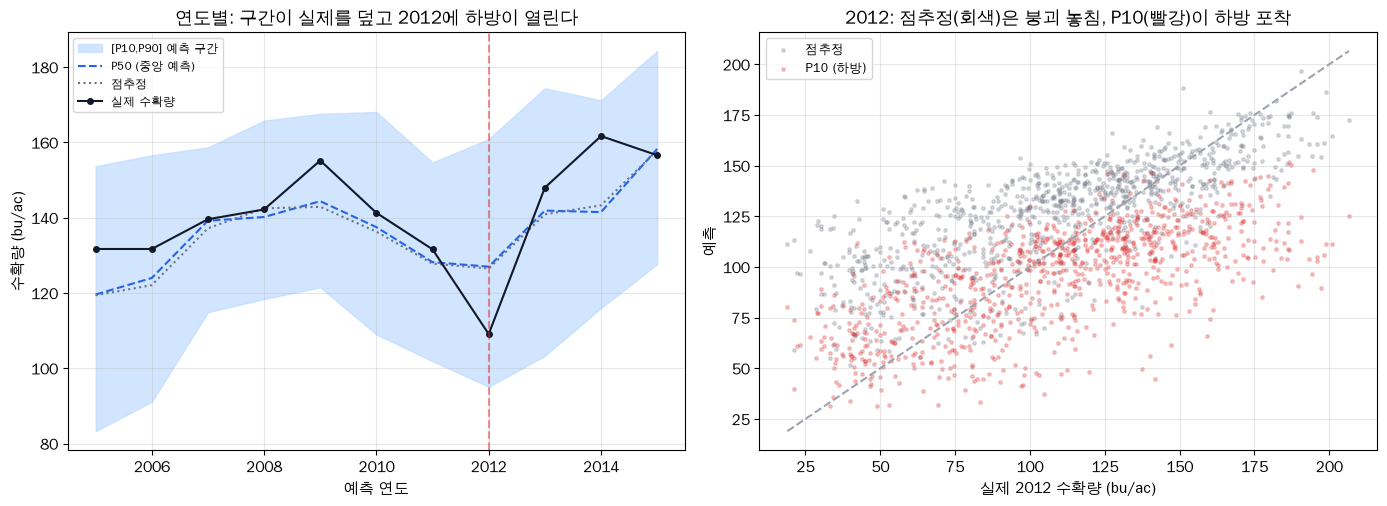

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
s = yr.sort_index()
# (왼쪽) 연도별 구간
ax[0].fill_between(s.index, s.P10, s.P90, color="#bfdbfe", alpha=.7, label="[P10,P90] 예측 구간")
ax[0].plot(s.index, s.P50, "--", color="#2563eb", label="P50 (중앙 예측)")
ax[0].plot(s.index, s["실제"] + s["점추정편향"], ":", color="#6b7280", label="점추정")
ax[0].plot(s.index, s["실제"], "o-", color="#111827", ms=4, label="실제 수확량")
ax[0].axvline(2012, color="#dc2626", ls="--", alpha=.5)
ax[0].set(xlabel="예측 연도", ylabel="수확량 (bu/ac)", title="연도별: 구간이 실제를 덮고 2012에 하방이 열린다")
ax[0].legend(fontsize=8.5)
# (오른쪽) 2012 카운티별
lim = [g12.actual.min(), g12.actual.max()]
ax[1].plot(lim, lim, "--", color="#9ca3af")
ax[1].scatter(g12.actual, g12.point, s=6, alpha=.25, color="#6b7280", label="점추정")
ax[1].scatter(g12.actual, g12.p10, s=6, alpha=.25, color="#dc2626", label="P10 (하방)")
ax[1].set(xlabel="실제 2012 수확량 (bu/ac)", ylabel="예측",
          title="2012: 점추정(회색)은 붕괴 놓침, P10(빨강)이 하방 포착")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 변수 중요도 (Feature Importance)

**① 무엇:** 모델이 어떤 피처에 의존해 예측하는지 본다.
**② 왜:** '블랙박스'를 열어 결과를 신뢰할 수 있는지 확인한다(농학 상식과 맞는지).
**③ 코드:** 피처를 하나씩 무작위로 섞어 예측이 얼마나 나빠지는지(순열 중요도)로 잰다.

상위 5개: whc(0.122), edd(0.121), spH(0.105), tmmx_jul(0.096), clay(0.088)


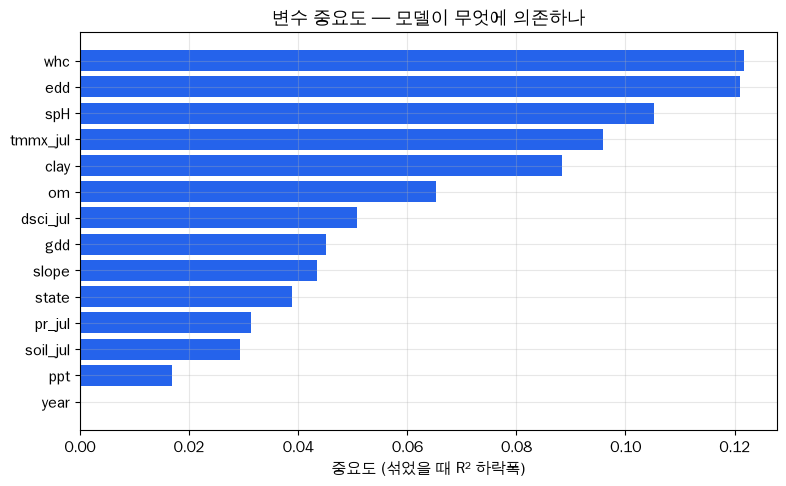

In [10]:
from sklearn.inspection import permutation_importance
# 2011년까지 학습 → 2012~2015로 중요도 측정
tr = df[df.year <= 2011]; te = df[df.year >= 2012]
feats = [c for c in FEATURES if tr[c].nunique(dropna=True) >= 2]
m = make_model("point").fit(tr[feats], tr[TARGET])
pi = permutation_importance(m, te[feats], te[TARGET], n_repeats=10, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=feats).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color="#2563eb")
ax.set(xlabel="중요도 (섞었을 때 R² 하락폭)", title="변수 중요도 — 모델이 무엇에 의존하나")
plt.tight_layout(); plt.show()
print("상위 5개:", ", ".join("%s(%.3f)" % (k, v) for k, v in imp.sort_values(ascending=False).head(5).items()))

**④ 결과 해석 (성능이 좋은/부족한 이유):**
- **잘 되는 점:** 점추정 R²·RMSE 가 준수하고, 무엇보다 **구간 커버리지가 목표 80%에 근접** →
  "80% 구간"이라는 경고가 통계적으로 정직하다. 2012년에 **하방(P10)이 붕괴에 근접**해 위험을 알렸다.
- **부족한 점 (정직하게):** 점추정으로 **2012년의 정확한 숫자는 여전히 못 맞힌다**(위로 +16 치우침).
  트리 모델은 '한 번도 본 적 없는 극단'을 외삽(extrapolation)하지 못하기 때문이다. 그래서 우리는
  '정확한 숫자'가 아니라 '**하방 위험**'을 예측하는 방식으로 문제를 바꾼 것이다.
- **핵심 피처:** 토양 보수력(whc), 극한고온(edd), 7월 가뭄(dsci_jul), 7월 최고기온(tmmx_jul)이
  상위 — **물(수분)과 고온**이 수확량의 핵심이라는 농학 상식과 일치한다.

**⑤ 다음 단계:** 이 P10(하방 위험) 값을 '작물 배분 최적화'의 입력으로 넣으면, "나쁜 해에도 손실이
적은 안전한 작물 배치"를 찾을 수 있다(강건 최적화). 이것이 이 프로젝트의 최종 목표다.

## 6. 재현성 (Reproducibility)

**동일한 결과를 재현하는 방법:**

1. **필요한 라이브러리** (버전은 requirements.txt 참고):
   `numpy`, `pandas`, `scikit-learn`, `matplotlib` — 이 4개면 충분하다.
2. **실행 순서:** 이 노트북의 셀을 **위에서 아래로 순서대로** 실행한다(메뉴 → 모두 실행).
   외부 데이터가 필요 없다(노트북에 내장).
3. **랜덤 시드(Random Seed):** 모든 모델에 `random_state=0` 을 고정했다. → 몇 번을 돌려도
   **똑같은 숫자**가 나온다.
4. **결정성(determinism):** 데이터 분리도 무작위가 아니라 '연도 순서'로 정해지므로, 재현 시
   흔들림이 없다.

아래 셀은 지금 실행 환경의 라이브러리 버전을 출력한다 — 남과 결과가 다르면 여기부터 비교하면 된다.

In [11]:
import sys, sklearn, numpy, pandas, matplotlib
print("Python     :", sys.version.split()[0])
print("numpy      :", numpy.__version__)
print("pandas     :", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib :", matplotlib.__version__)
print("\n랜덤 시드 고정(random_state=0) + 연도순 분리 → 항상 동일한 결과가 재현됩니다.")

Python     : 3.11.15
numpy      : 2.4.6
pandas     : 3.0.3
scikit-learn: 1.9.0
matplotlib : 3.11.0

랜덤 시드 고정(random_state=0) + 연도순 분리 → 항상 동일한 결과가 재현됩니다.
